In [4]:
#Height is dependent feature
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
#Reading the data set
df = pd.read_csv('height-weight.csv')

In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [7]:
#let's understand the relation ship between height and weight

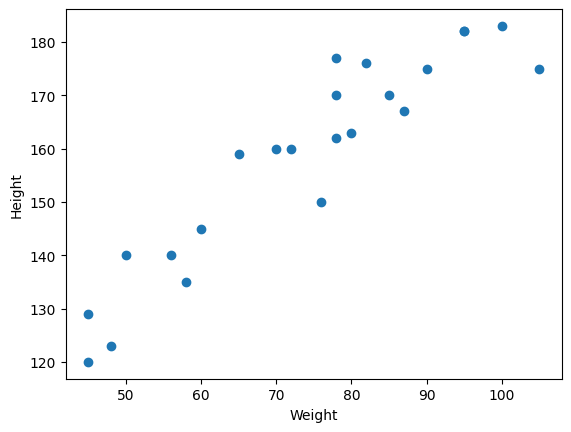

In [12]:
#Scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()
#Clearly, we can see that as the weight is increasing, height is also increasing.

In [13]:
#To find whether this relation is negative or positive we will use the correlation
df.corr()
#Weight to Height -> 0.931142 , clealy, it is highly correlated.

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


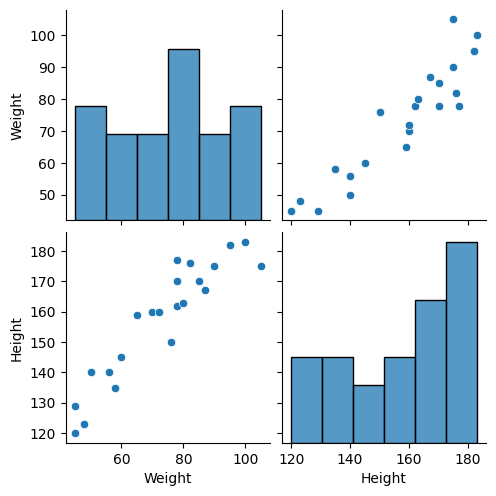

In [14]:
#Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [15]:
#Clealy, positive realtion is there, and since there is only one independent feature, we can say that linearly correlated.


In [20]:
#Dividing the features as: independent and dependent features
# X = df['Weight'] #it gives a series, so we will add one more []
X = df[['Weight']] #it gives a dataframe ->make sure independent feature be a dataframe or a 2D array
y = df['Height'] #-> dependent feature -> can be in series or 1D array

In [21]:
X_series = df['Weight']
np.array(X_series).shape

(23,)

In [24]:
# Import the function used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing subsets
# X represents the input features
# y represents the target/labels
#
# 75% of the data is used for training (X_train, y_train)
# 25% of the data is used for testing (X_test, y_test)
#
# The model learns patterns from X_train and y_train
# The trained model is later evaluated using X_test and y_test
#
# random_state=42 ensures that the split is reproducible
# (the same split will occur every time the code is run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)



In [25]:
X_train.shape # it should be in 2D

(17, 1)

In [27]:
# Standardization step for Linear Regression
# Standardization scales the features so that they have:
# - mean = 0
# - standard deviation = 1
# This helps many machine learning algorithms perform better,
# especially those sensitive to feature scale.

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# - fit(): computes the mean and standard deviation from X_train
# - transform(): scales X_train using those computed values
#
# IMPORTANT:
# We fit ONLY on the training data to avoid data leakage.
# The same scaler will later be used to transform the test data.
X_train= scaler.fit_transform(X_train)

In [28]:
# Scale the test data using the same scaler fitted on the training data
# transform() applies the mean and standard deviation learned from X_train
#
# We do NOT use fit_transform() here to avoid data leakage.
# Using fit_transform() on test data would incorrectly allow the model
# to learn information from the test set.
#
# This ensures that both training and test data are on the same scale.
X_test = scaler.transform(X_test)

In [29]:
#Apply linear regression
from sklearn.linear_model import LinearRegression

In [31]:
# Initialize the Linear Regression model
# This creates an instance of the LinearRegression class
# but does not train the model yet
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

# Train (fit) the linear regression model
# The model learns the relationship between the input features (X_train)
# and the target variable (y_train) by estimating the best-fit line
# that minimizes the prediction error (least squares method)
regression.fit(X_train, y_train)

LinearRegression()

In [34]:
# Print the coefficients (slopes) of the linear regression model
# Each coefficient represents how much the target variable (y)
# changes for a one-unit increase in the corresponding feature,
# assuming all other features are held constant
print("Coefficient or slope: ", regression.coef_)

# Print the intercept (bias term) of the model
# The intercept is the predicted value of y when all input features are zero
# It represents where the regression line crosses the y-axis
print("Intercept: ", regression.intercept_)

# This value means that for every 1-unit increase in the input feature, the predicted target value (y) increases by about 17.3 units.
# Intercept (156.47): This is the predicted value of y when the input feature equals 0.It represents the point where the regression line crosses the y-axis.

Coefficient or slope:  [17.2982057]
Intercept:  156.47058823529412


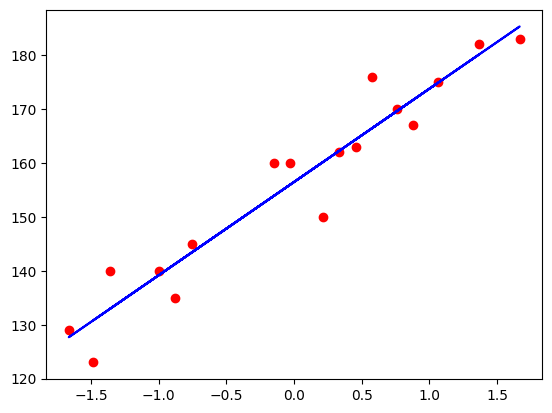

In [37]:
# Plot the training data and the best-fit regression line

# Create a scatter plot of the training data
# X_train values are plotted on the x-axis
# y_train values are plotted on the y-axis
# Red dots represent the actual observed data points
plt.scatter(X_train, y_train, color='red')

# Plot the regression (best-fit) line
# regression.predict(X_train) computes the predicted y-values
# for each X value using the trained linear regression model
# The blue line shows how well the model fits the training data
plt.plot(X_train, regression.predict(X_train), color='blue')

In [39]:
# Prediction of test data using the linear regression equation

# Linear regression follows the equation:
# y = intercept + (coefficient × feature_value)

# From the trained model:
# Intercept = 156.470
# Coefficient (weight) = 17.299

# Therefore, for any test input X_test:
# Predicted height (y_pred_test) is calculated as:
# y_pred_test = 156.470 + 17.299 * X_test

In [38]:
# Make predictions on the test dataset
# The trained linear regression model uses X_test as input
# to predict the corresponding target values (y_pred)
#
# These predictions are used to evaluate how well the model
# generalizes to unseen data
y_pred = regression.predict(X_test)

In [43]:
# Performance metrics to evaluate the regression model

# Import evaluation metrics for regression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Mean Squared Error (MSE)
# Measures the average of the squared differences between
# the actual values (y_test) and the predicted values (y_pred)
# Penalizes larger errors more heavily
mse = mean_squared_error(y_test, y_pred)

# Mean Absolute Error (MAE)
# Measures the average of the absolute differences between
# actual and predicted values
# Easier to interpret because it is in the same units as the target
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error (RMSE)
# Square root of MSE
# Brings the error back to the original units of the target variable
# Sensitive to large prediction errors
rmse = np.sqrt(mse)

# Print the performance metrics
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

# Model Performance Output Explanation

# Mean Squared Error (MSE): 114.84
# On average, the square of the difference between the actual values
# and the predicted values is about 114.84.
# Because errors are squared, larger mistakes have a bigger impact
# on this metric.

# Mean Absolute Error (MAE): 9.67
# On average, the model’s predictions are off by about 9.67 units
# from the actual target values.
# This is often the easiest metric to interpret because it is in
# the same units as the target variable.

# Root Mean Squared Error (RMSE): 10.72
# This is the square root of MSE, which brings the error back to the
# original units of the target variable.
# It indicates that the model typically makes an error of about
# 10.7 units when making predictions.

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605


In [46]:
# Calculating R-squared (R²) score

# Import R² evaluation metric
from sklearn.metrics import r2_score

# Compute the R² score by comparing actual values (y_test)
# with predicted values (y_pred)
#
# R² represents the proportion of variance in the target variable
# that is explained by the independent variable(s)
score = r2_score(y_test, y_pred)

# Print the R² score
print(score)

# R² ranges from -∞ to 1
# R² = 1   → Perfect prediction
# R² = 0   → Model explains no variance (same as predicting the mean)
# R² < 0   → Model performs worse than a simple mean prediction
#
# Example:
# R² = 0.85 means 85% of the variation in the target variable
# is explained by the model

0.7360826717981276


In [47]:
# Calculating Adjusted R-squared (Adjusted R²)

# Adjusted R² modifies the R² score by accounting for:
# - the number of observations (len(y_test))
# - the number of independent features (X_test.shape[1])
#
# Unlike R², Adjusted R² penalizes the addition of unnecessary features
# and only increases if a new feature improves the model more than
# would be expected by chance.

adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

# Print the Adjusted R² score
print(adjusted_r2)

0.6701033397476595


In [51]:
# Now comparing OLS (Ordinary Least Squares) linear regression
# OLS is a statistical method used to estimate the parameters
# of a linear regression model by minimizing the sum of squared errors

# Import the statsmodels library for statistical modeling
import statsmodels.api as sm

# Create and fit an OLS regression model
# sm.OLS(endog, exog)
#
# Parameters passed:
# y_train → endog (dependent/target variable)
# X_train → exog (independent/input feature(s))
#
# The model learns the relationship between X_train and y_train
# by estimating coefficients that minimize the squared residuals
#
# NOTE:
# Unlike sklearn, statsmodels does NOT automatically add an intercept.
# If an intercept is required, a constant column must be added manually.
model = sm.OLS(y_train, X_train).fit()

# Use the trained OLS model to make predictions on the test data
# Parameters passed:
# X_test → independent variables for which predictions are required
#
# The method applies the learned coefficients to X_test
# to compute predicted target values
prediction = model.predict(X_test)

# Print the predicted values for the test dataset
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [52]:
print(model.summary()) # for OLS

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Mon, 29 Dec 2025   Prob (F-statistic):                       0.664
Time:                        04:14:33   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [55]:
# Prediction for new (unseen) data

# [[72]] → New input value for the independent variable
# It is wrapped in double brackets to make it a 2D array
# because sklearn expects input in the shape: (n_samples, n_features)

# scaler.transform([[72]])
# - Uses the SAME scaler that was fitted on X_train
# - Converts the raw value (72) into its standardized form
# - This ensures consistency with how the model was trained

# regression.predict(...)
# - Uses the trained linear regression model
# - Applies the learned intercept and coefficient
# - Returns the predicted target value for the new input

predicted_value = regression.predict(scaler.transform([[72]]))

# Print the predicted output
print(predicted_value)

[155.97744705]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
